sklearn's spectral clustering does everything end-to-end: builds the graph..(connectivity graph), computes the laplacian graph, runs eigendecomposition, then clusters in the embedded space.

In [1]:
import numpy as np
from sklearn.cluster import SpectralClustering

In [2]:
# X is the dataset (m,n)
X = np.random.randn(300,10) # example: 300 samples, 10 features

sc = SpectralClustering(
    n_clusters = 3, # number of clusters u want
    affinity='rbf', # how to build the graph (rbf = Gaussian kernel)
    gamma = 1.0, # kernel bandwidth for ebf
    n_neighbors = 10, # useful only if affinity = nearest_neighbors
    assign_labels = 'kmeans', # final clustering step kmeans or discretize
    random_state=42,
    n_jobs = -1
)


- significance of the arguments supplied to this function:
  - affinity: controls the construction of the neighborhood graph (affinity controls how similarity beyween every pair of points is computed to construct the neighborhood graph)
  - concretely, it produces the affinity matrix A, an mxm symmetric matrix where A[i,j] = how similar points i and j are. can either use rbf or nearest_neighbors affinity
  - to assign labels, can either use kmeans or use the discretize option...
  - discretize key insight: in theory of your data has k perfectly separated clusters, the eigenmatrix (input matrix), would have a very specific structure - where each row would be exactly one of the K standard basis vectors i.e. [1,0,0] | [0, 1, 0], | [0, 0, 1] for k=3.....in ptherwords the assumption is that the vectors should be separable.
  - In practice, the matrix after eigendecomposition of the laplacian is noisy.... discretize tries to find the closest rotation of this matrix (an orthogonal transformation), such that the rotated matrix looks as close as possible to the above perfect matrix which appears clearly separable... 
  - Concretely:
    - normalise rows of U to unit length | 
    - find rotation matrix R that maximises how one-hot-like U.R looks
    - assign each point to whichever column has the largest value in U.R
 - if clusters are well-separated and are roughly equally sized: kmeans is fine
 - for non-convex or very unequal clusyers: discretize is more stable
 - also, kmeans keeps giving different results across runs... while discretize is more deterministic
 - also when k is large - discretize is more robust

kmeans can get stuck in local optima...while discretize is deterministic and tends to be more stable when the spectral embedding is messy or the clusyers are geometrically weird in the embedding space..
- newer versions package: cluster_qr
  - discretize: what it does is that it finds R (orthogonal) that maximizes how one-hot-like U.R looks 
    - however this is essentially a procrustes problem - expensive because it's iterative and involves SVD in a loop until convergence
  - cluster_qr: instead of searching for a rotation, it uses QR decomposition with column pivoting directly on Ut (the transpose of the eigenvecvtor matrix)
  - same destination as discretize but different paths with cluster_qr being more efficient

Important to know:
- Spectral clustering hardcodes n_components = n_clusters internally. 

**manual pipeline:**

In [3]:
import numpy as np
from sklearn.manifold import SpectralEmbedding
from sklearn.cluster import KMeans, AgglomerativeClustering
import matplotlib.pyplot as plt

In [4]:
X = np.random.randn(300, 10)
k = 3 # number of clusters

In [6]:
# ------ step 1: spectralo embedding
se = SpectralEmbedding(
    n_components = k, # embed into K-dim space (one per cluster)
    affinity = 'rbf',
    gamma = 1.0,
    random_state = 42,
    n_jobs = -1
)

X_emb = se.fit_transform(X) # shape: (m, K): the eigenvector matrix

In [7]:
# ------ step 2: cluster the embedding
km = KMeans(n_clusters=k, random_state=42, n_init='auto')
labels = km.fit_predict(X_emb)

In [8]:
# ---- optional: inspect the affinity matrix/laplacian
A = se.affinity_matrix_
print("Embedding shape: ", X_emb.shape)
print("Labels: ", labels[:10])

Embedding shape:  (300, 3)
Labels:  [0 0 0 0 0 0 0 0 0 0]


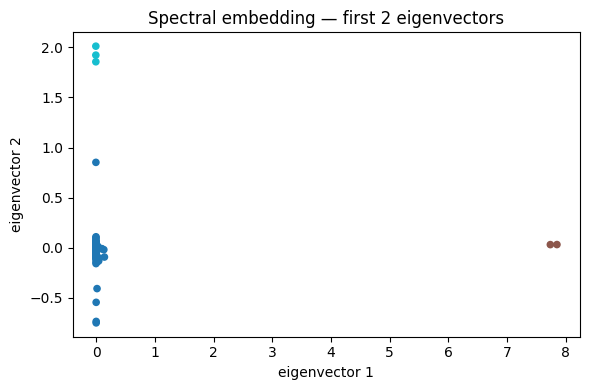

In [9]:
# --- visualise the 2D projection (use first 2 eigenvectors) ---
plt.figure(figsize=(6, 4))
plt.scatter(X_emb[:, 0], X_emb[:, 1], c=labels, cmap='tab10', s=20)
plt.title("Spectral embedding — first 2 eigenvectors")
plt.xlabel("eigenvector 1")
plt.ylabel("eigenvector 2")
plt.tight_layout()
plt.show()

spectral clustering forces **n_components = n_clusters**. It is making a strong assumption that the k-th eigenvector is the last one carrying useful cluster information. This is true in the ideal noiseless case but real data is messy. Some cluster boundary signal can bleed into other eigenvectors... 
- by embedding into a higher dimensional spectral space first, then letting k-means operate in that ricjer space, we're being more conservative about the information to discard...

In [ ]:
from sklearn.manifold import SpectralEmbedding
from sklearn.cluster import KMeans

X = ...  # your (m, n) dataset
K = 3    # actual number of clusters you want

# embed into MORE dimensions than K
se = SpectralEmbedding(n_components=10, affinity='rbf', gamma=1.0)
X_emb = se.fit_transform(X)   # shape: (m, 10)

# cluster down to K in that richer space
km = KMeans(n_clusters=K, random_state=42, n_init='auto')
labels = km.fit_predict(X_emb)  # shape: (m,)

- tradeoff: higher eigenvectors do not just carry residual cluster signal - they also carry boise so we're handing the clustering algo a richer but also noisier space. 

recommendation:
- can use the eigengap to find the right cutoff:

In [ ]:
from sklearn.metrics.pairwise import rbf_kernel
# above:  imports the func that computes the rbf/gaussian kerne; between all pairs of points (this is how u build the affinity matrix A outside of spectral clustering)
from scipy.sparse.csgraph import laplacian
# import's scipy's graph laplacian builder...takes an affinity/adjacency matrix and returns a laplacian matrix
from scipy.linalg import eigh
# eigh: symmetric matrix eigendecomposition solver: eigh 
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
A = rbf_kernel(X, gamma=1.0) # build the mxm affinity matrix.

In [12]:
A.shape, X.shape

((300, 300), (300, 10))

In [ ]:
L = laplacian(A, normed=True) # constructs the normalised graph laplacian from A. normed=True gives you the normalised version instead of the raw version

In [14]:
L.shape

(300, 300)

In [ ]:
eigenvalues, _ = eigh(L) # eigh returns eigenvalues already sorted ascending - smallest first | so  this is the 20 smallest eigenvalues. So, the plot shows the bottom of the spectrum
# not the top. 
# decomposes L into eigenvalues and eigenvectors...we only need eigenvalues to find the eigengap...

In [18]:
gaps = np.diff(eigenvalues[:20]) # differences between consecutive eigenvalues...result is that each value is how much the eigenvalue jumped between successive indices... a big jump = eigengap
# big jump = eigengap = the boundary between signal and noise

In [19]:
gaps.shape

(19,)

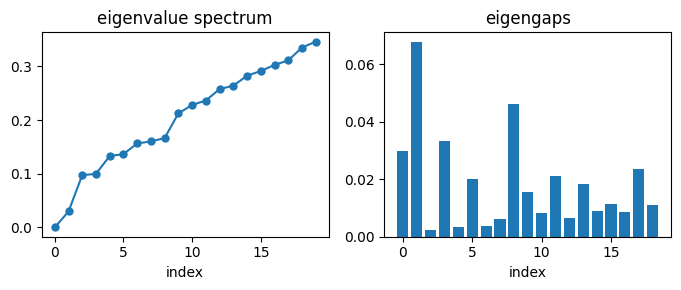

In [21]:
plt.figure(figsize=(7,3))
plt.subplot(1,2,1)
plt.plot(eigenvalues[:20], 'o-', markersize=5)
plt.title('eigenvalue spectrum')
plt.xlabel('index')

plt.subplot(1,2,2)
plt.bar(range(len(gaps)), gaps)
plt.title('eigengaps')
plt.xlabel('index')
plt.tight_layout()
plt.show()

In [22]:
# the biggest gap tells you where noise starts
best_n_components = np.argmax(gaps) + 1
print(f"suggested n_components: {best_n_components}")

suggested n_components: 2


Set n_components to just before the biggest gap — that's where real cluster signal ends and noise begins. Your n_clusters for k-means is a separate decision based on domain knowledge or elbow/silhouette analysis.

other good clustering algos that work with spectral embedding:
-  GMM
-  Agglomerative
-  DBSCAN
-  HDBSCAN